In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import random

np.random.seed(42)
random.seed(42)


In [8]:
# ─── Human chromosome sizes (hg38, approximate Mb) ─────────────────────────
CHR_SIZES = {
    'chr1': 249, 'chr2': 242, 'chr3': 198, 'chr4': 190, 'chr5': 181,
    'chr6': 171, 'chr7': 159, 'chr8': 145, 'chr9': 138, 'chr10': 133,
    'chr11': 135, 'chr12': 133, 'chr13': 114, 'chr14': 107, 'chr15': 102,
    'chr16': 90,  'chr17': 84,  'chr18': 80,  'chr19': 59,  'chr20': 63,
    'chr21': 47,  'chr22': 51,  'chrX': 156,
}
CHROMS  = list(CHR_SIZES.keys())
BIN_SIZE = 5   # Mb resolution
N_CELLS  = 100

# Build flat bin list and chromosome-to-index mapping
bin_labels  = []
chr_bin_idx = {}   # chrom -> (start_idx, end_idx)
idx = 0
for chrom in CHROMS:
    n_bins = CHR_SIZES[chrom] // BIN_SIZE
    chr_bin_idx[chrom] = (idx, idx + n_bins)
    for i in range(n_bins):
        bin_labels.append(f"{chrom}:{i*BIN_SIZE}-{(i+1)*BIN_SIZE}Mb")
    idx += n_bins

N_BINS = len(bin_labels)
print(f"Bin size  : {BIN_SIZE} Mb")
print(f"Total bins: {N_BINS}")
print(f"Chromosomes tracked: {', '.join(CHROMS)}")


Bin size  : 5 Mb
Total bins: 596
Chromosomes tracked: chr1, chr2, chr3, chr4, chr5, chr6, chr7, chr8, chr9, chr10, chr11, chr12, chr13, chr14, chr15, chr16, chr17, chr18, chr19, chr20, chr21, chr22, chrX


In [9]:
# ─── Structural Variant Functions ───────────────────────────────────────────
# Each function mutates cn in-place and returns a metadata dict.

def apply_full_deletion(cn, chrom):
    """Lose one copy of the entire chromosome (monosomy / whole-chr loss)."""
    s, e = chr_bin_idx[chrom]
    cn[s:e] = np.maximum(cn[s:e] - 1, 0)
    return {'type': 'full_deletion', 'chrom': chrom,
            'length_Mb': (e - s) * BIN_SIZE}


def apply_partial_deletion(cn, chrom):
    """Delete a random contiguous intra-chromosomal segment."""
    s, e = chr_bin_idx[chrom]
    n = e - s
    if n < 2:
        return {'type': 'partial_deletion', 'chrom': chrom, 'length_Mb': 0}
    max_len = max(2, int(n * 0.6))
    length  = np.random.randint(1, max_len)
    start   = np.random.randint(s, e - length)
    cn[start:start + length] = np.maximum(cn[start:start + length] - 1, 0)
    return {'type': 'partial_deletion', 'chrom': chrom,
            'bin_start': start, 'bin_end': start + length,
            'length_Mb': length * BIN_SIZE}


def apply_duplication(cn, chrom):
    """Gain one copy of a segment (focal or whole-chromosome)."""
    s, e = chr_bin_idx[chrom]
    n = e - s
    if np.random.random() < 0.25:          # whole-chr duplication
        cn[s:e] += 1
        return {'type': 'duplication', 'chrom': chrom,
                'length_Mb': n * BIN_SIZE, 'whole_chr': True}
    max_len = max(2, int(n * 0.5))
    length  = np.random.randint(1, max_len)
    start   = np.random.randint(s, e - length)
    cn[start:start + length] += 1
    return {'type': 'duplication', 'chrom': chrom,
            'bin_start': start, 'bin_end': start + length,
            'length_Mb': length * BIN_SIZE, 'whole_chr': False}


def apply_fragmentation(cn, chrom):
    """
    Chromothripsis-like shredding: alternating retained / deleted fragments
    across a chromosomal region, creating a 'shattered' copy-number pattern.
    """
    s, e = chr_bin_idx[chrom]
    n = e - s
    svs = []
    region_len   = max(4, int(n * np.random.uniform(0.4, 1.0)))
    region_start = np.random.randint(s, max(s + 1, e - region_len))
    frag_size    = np.random.randint(1, 3)   # 5–10 Mb fragments

    pos = region_start
    while pos < region_start + region_len:
        seg_end = min(pos + frag_size, region_start + region_len)
        if np.random.random() < 0.60:           # delete with prob 0.6
            loss = np.random.randint(1, min(3, int(cn[pos:seg_end].max()) + 1) or 2)
            cn[pos:seg_end] = np.maximum(cn[pos:seg_end] - loss, 0)
            svs.append({'type': 'fragmentation', 'chrom': chrom,
                        'bin_start': pos, 'bin_end': seg_end,
                        'length_Mb': (seg_end - pos) * BIN_SIZE})
        pos = seg_end
    return svs


def apply_fusion(cn, chrom1, chrom2):
    """
    End-to-end chromosome fusion: the q-arm of chrom2 is appended to chrom1.
    Models telomeric fusions common in osteosarcoma.
    The junction region of chrom2 is gained on chrom1; chrom2 loses it.
    """
    s1, e1 = chr_bin_idx[chrom1]
    s2, e2 = chr_bin_idx[chrom2]
    n2 = e2 - s2
    flen = max(1, n2 // 5)          # fuse first ~20 % of chrom2
    cn[e1 - flen:e1] += 1           # gain at chrom1 q-tip
    cn[s2:s2 + flen] = np.maximum(cn[s2:s2 + flen] - 1, 0)   # loss from chrom2
    return {'type': 'fusion', 'chrom1': chrom1, 'chrom2': chrom2,
            'fusion_length_Mb': flen * BIN_SIZE}


def apply_translocation(cn, donor, recipient):
    """
    Unbalanced translocation: a segment is cut from donor and inserted
    into recipient (donor loses one copy; recipient gains one copy).
    """
    sd, ed = chr_bin_idx[donor]
    sr, er = chr_bin_idx[recipient]
    nd = ed - sd
    if nd < 2:
        return {'type': 'translocation', 'donor': donor,
                'recipient': recipient, 'length_Mb': 0}
    length    = np.random.randint(1, max(2, nd // 3))
    seg_start = np.random.randint(sd, ed - length)
    ins_pos   = np.random.randint(sr, er)

    # recipient gains
    cn[ins_pos:min(ins_pos + length, er)] += 1
    # donor loses
    cn[seg_start:seg_start + length] = np.maximum(
        cn[seg_start:seg_start + length] - 1, 0)

    return {'type': 'translocation', 'donor': donor, 'recipient': recipient,
            'bin_start': seg_start, 'bin_end': seg_start + length,
            'length_Mb': length * BIN_SIZE}


print("Structural variant functions defined.")
print("SVs available: full_deletion, partial_deletion, duplication,")
print("               fragmentation (chromothripsis), fusion, translocation")


Structural variant functions defined.
SVs available: full_deletion, partial_deletion, duplication,
               fragmentation (chromothripsis), fusion, translocation


In [10]:
# ─── Main Simulation: 100 Osteosarcoma-like Cells ───────────────────────────
#
# Osteosarcoma hallmarks (see Brohl et al. Cell 2024 and prior literature):
#   • Near-triploid genome (mean ploidy ≈ 3)
#   • High frequency of chromothripsis (~40 % of tumors)
#   • 2–6 inter-chromosomal translocations per tumour
#   • Focal amplifications (e.g. 6p21, 8q24, 17p13) and deletions (13q, 17p)
#   • Whole-chromosome gains (chr1q, chr8) and losses (chr13, chr17p)
#   • Occasional end-to-end chromosome fusions

def simulate_osteosarcoma(n_cells=N_CELLS):
    """
    Returns
    -------
    cn_matrix    : (n_cells, N_BINS) integer copy-number array
    count_matrix : (n_cells, N_BINS) simulated scDNA read-count array
    sv_log       : list of length n_cells; each entry is a list of SV dicts
    """
    cn_matrix = np.zeros((n_cells, N_BINS), dtype=float)
    sv_log    = []

    for cell in range(n_cells):
        # ── Baseline: near-triploid with per-chr ploidy noise ─────────────
        cn = np.zeros(N_BINS, dtype=float)
        for chrom in CHROMS:
            s, e = chr_bin_idx[chrom]
            base = np.random.choice([2, 2, 3, 3, 3, 4],
                                    p=[0.07, 0.08, 0.35, 0.30, 0.15, 0.05])
            cn[s:e] = base

        cell_svs = []

        # ── Inter-chromosomal translocations (2–6 per cell) ───────────────
        for _ in range(np.random.randint(2, 7)):
            donor, recip = random.sample(CHROMS, 2)
            cell_svs.append(apply_translocation(cn, donor, recip))

        # ── Focal / arm-level partial deletions (2–5 per cell) ───────────
        for _ in range(np.random.randint(2, 6)):
            cell_svs.append(apply_partial_deletion(cn, random.choice(CHROMS)))

        # ── Focal / whole-chr duplications (1–4 per cell) ─────────────────
        for _ in range(np.random.randint(1, 5)):
            cell_svs.append(apply_duplication(cn, random.choice(CHROMS)))

        # ── Whole-chromosome deletions (0–2 per cell) ─────────────────────
        for _ in range(np.random.choice([0, 1, 2], p=[0.50, 0.35, 0.15])):
            cell_svs.append(apply_full_deletion(cn, random.choice(CHROMS)))

        # ── Chromothripsis / fragmentation (40 % of cells, 1–2 chrs) ──────
        if np.random.random() < 0.40:
            for _ in range(np.random.randint(1, 3)):
                frags = apply_fragmentation(cn, random.choice(CHROMS))
                cell_svs.extend(frags)

        # ── Chromosome fusion (20 % of cells) ─────────────────────────────
        if np.random.random() < 0.20:
            c1, c2 = random.sample(CHROMS, 2)
            cell_svs.append(apply_fusion(cn, c1, c2))

        cn = np.maximum(cn, 0)
        cn_matrix[cell] = cn
        sv_log.append(cell_svs)

    # ── Simulate read counts (negative binomial) ──────────────────────────
    # Mean coverage scaled by copy number: mean_counts = CN × (depth / 2)
    mean_depth  = 60     # reads per bin at diploid CN = 2
    dispersion  = 4      # NB dispersion r; smaller → more overdispersed
    mean_counts = cn_matrix * (mean_depth / 2.0)
    p_nb        = dispersion / (dispersion + mean_counts + 1e-9)
    count_matrix = np.random.negative_binomial(
        dispersion, np.clip(p_nb, 1e-9, 1 - 1e-9)
    ).astype(float)
    count_matrix[cn_matrix == 0] = 0   # zero-copy bins → no reads

    return cn_matrix.astype(int), count_matrix, sv_log


cn_matrix, count_matrix, sv_log = simulate_osteosarcoma(N_CELLS)

print(f"Copy-number matrix : {cn_matrix.shape[0]} cells × {cn_matrix.shape[1]} bins")
print(f"Count matrix       : {count_matrix.shape[0]} cells × {count_matrix.shape[1]} bins")
print(f"Mean copy number   : {cn_matrix.mean():.2f}  (diploid baseline = 2)")
print(f"CN range           : {cn_matrix.min()} – {cn_matrix.max()}")
print(f"Mean read count/bin: {count_matrix.mean():.1f}")
print(f"Total SVs logged   : {sum(len(x) for x in sv_log)}")


Copy-number matrix : 100 cells × 596 bins
Count matrix       : 100 cells × 596 bins
Mean copy number   : 2.85  (diploid baseline = 2)
CN range           : 0 – 6
Mean read count/bin: 85.8
Total SVs logged   : 1752


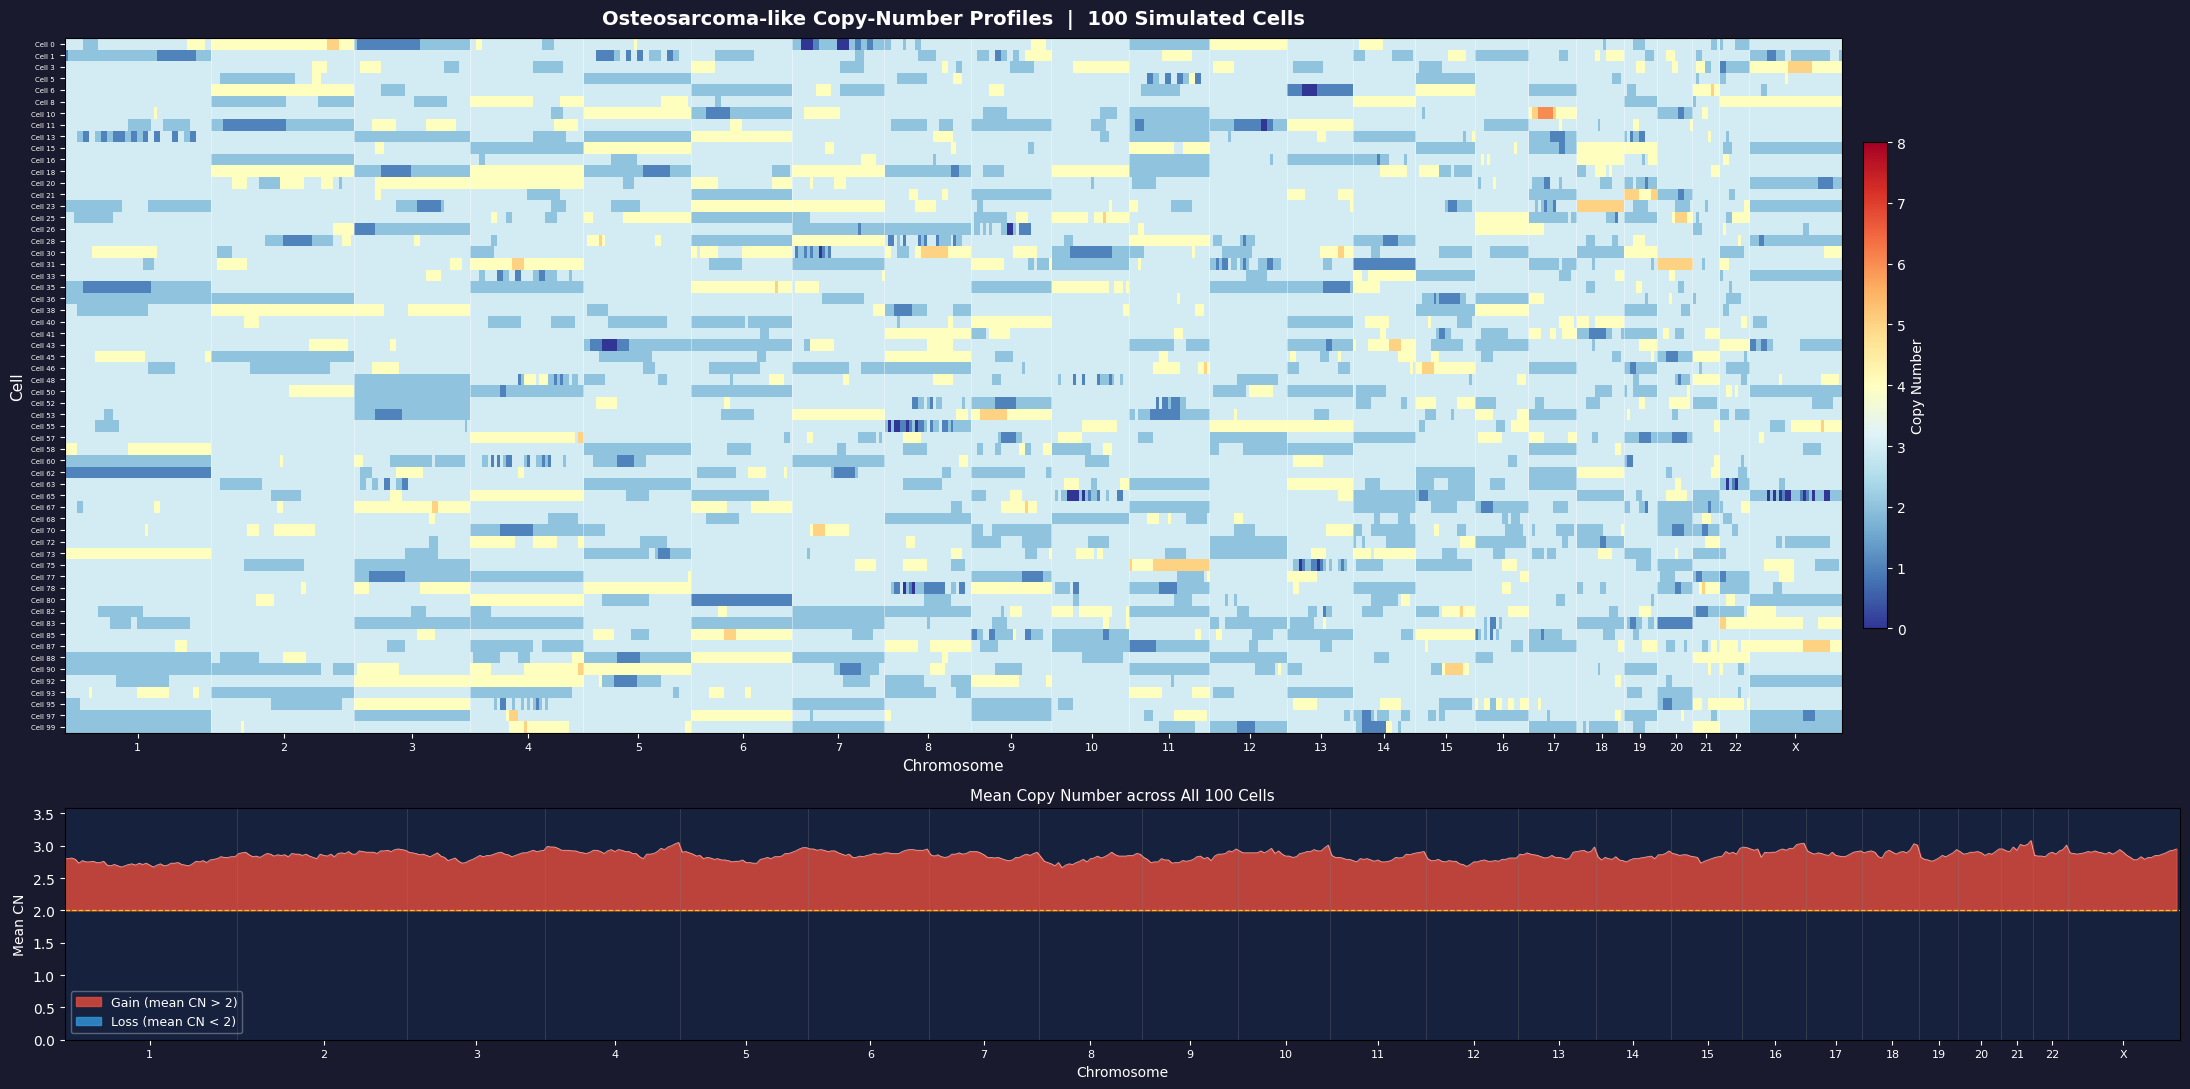

In [11]:
# ─── Visualization 1: Copy-Number Heatmap ────────────────────────────────────
# Show CN profiles (top) and genome-wide mean CN (bottom)

chr_boundaries = [chr_bin_idx[c][0] for c in CHROMS[1:]]
chr_midpoints  = [(chr_bin_idx[c][0] + chr_bin_idx[c][1]) // 2 for c in CHROMS]
chr_labels     = [c.replace('chr', '') for c in CHROMS]

# Subsample cells for visibility
sample_idx = np.linspace(0, N_CELLS - 1, min(60, N_CELLS), dtype=int)
cn_sub     = cn_matrix[sample_idx]

fig, axes = plt.subplots(2, 1, figsize=(22, 11),
                         gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    ax.set_facecolor('#16213e')

# ── Top panel: heatmap ───────────────────────────────────────────────────────
cn_clipped = np.clip(cn_sub, 0, 8)
cmap = plt.cm.RdYlBu_r
im = axes[0].imshow(cn_clipped, aspect='auto', cmap=cmap,
                    vmin=0, vmax=8, interpolation='nearest')
axes[0].set_title('Osteosarcoma-like Copy-Number Profiles  |  100 Simulated Cells',
                  fontsize=14, fontweight='bold', color='white', pad=10)
axes[0].set_ylabel('Cell', fontsize=11, color='white')
axes[0].set_yticks(range(len(sample_idx)))
axes[0].set_yticklabels([f'Cell {i}' for i in sample_idx],
                        fontsize=5, color='#cccccc')
axes[0].tick_params(colors='white')

for xb in chr_boundaries:
    axes[0].axvline(x=xb - 0.5, color='white', linewidth=0.6, alpha=0.5)
axes[0].set_xticks(chr_midpoints)
axes[0].set_xticklabels(chr_labels, fontsize=8, color='white')
axes[0].set_xlabel('Chromosome', fontsize=11, color='white')

cbar = plt.colorbar(im, ax=axes[0], shrink=0.7, pad=0.01)
cbar.set_label('Copy Number', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# ── Bottom panel: mean CN ─────────────────────────────────────────────────────
mean_cn = cn_matrix.mean(axis=0)
x = np.arange(N_BINS)
axes[1].fill_between(x, 2, mean_cn,
                     where=(mean_cn >= 2), color='#e74c3c', alpha=0.8,
                     label='Gain (mean CN > 2)')
axes[1].fill_between(x, 2, mean_cn,
                     where=(mean_cn < 2),  color='#3498db', alpha=0.8,
                     label='Loss (mean CN < 2)')
axes[1].plot(x, mean_cn, color='white', linewidth=0.5, alpha=0.6)
axes[1].axhline(2, color='yellow', linewidth=0.9, linestyle='--', alpha=0.7)
axes[1].set_xlim(0, N_BINS)
axes[1].set_ylim(0, mean_cn.max() + 0.5)
axes[1].set_title('Mean Copy Number across All 100 Cells',
                  fontsize=11, color='white', pad=6)
axes[1].set_ylabel('Mean CN', fontsize=10, color='white')
axes[1].set_xlabel('Chromosome', fontsize=10, color='white')
axes[1].tick_params(colors='white')
for xb in chr_boundaries:
    axes[1].axvline(x=xb - 0.5, color='gray', linewidth=0.5, alpha=0.4)
axes[1].set_xticks(chr_midpoints)
axes[1].set_xticklabels(chr_labels, fontsize=8, color='white')
axes[1].legend(framealpha=0.3, fontsize=9, labelcolor='white',
               facecolor='#16213e', edgecolor='white')
axes[1].set_facecolor('#16213e')

plt.tight_layout()
plt.savefig('osteosarcoma_cn_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


Structural variant summary (all 100 cells):
         SV_type  count
   fragmentation    672
   translocation    394
partial_deletion    366
     duplication    230
   full_deletion     67
          fusion     23

Mean SVs per cell : 17.5


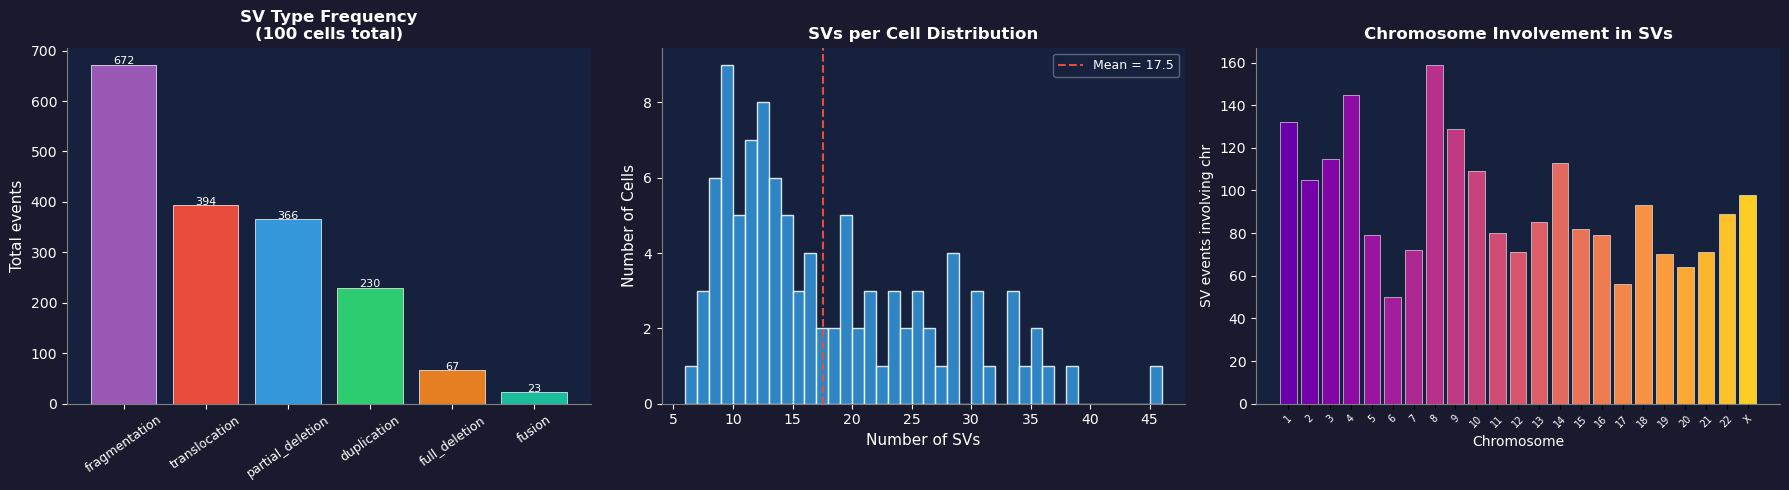

In [10]:
# ─── Visualization 2: SV Summary & Per-Cell Statistics ───────────────────────

sv_type_counts = Counter()
for cell_svs in sv_log:
    for sv in cell_svs:
        sv_type_counts[sv['type']] += 1

sv_df = (pd.DataFrame(sv_type_counts.items(), columns=['SV_type', 'count'])
           .sort_values('count', ascending=False)
           .reset_index(drop=True))

print("Structural variant summary (all 100 cells):")
print(sv_df.to_string(index=False))
print(f"\nMean SVs per cell : {sum(len(x) for x in sv_log) / N_CELLS:.1f}")

SV_COLORS = {
    'translocation'   : '#e74c3c',
    'partial_deletion': '#3498db',
    'duplication'     : '#2ecc71',
    'fragmentation'   : '#9b59b6',
    'full_deletion'   : '#e67e22',
    'fusion'          : '#1abc9c',
}

svs_per_cell = [len(x) for x in sv_log]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    ax.set_facecolor('#16213e')

# ── Panel 1: SV type bar chart ───────────────────────────────────────────────
bars = axes[0].bar(sv_df['SV_type'], sv_df['count'],
                   color=[SV_COLORS.get(t, 'gray') for t in sv_df['SV_type']],
                   edgecolor='white', linewidth=0.5)
axes[0].set_title('SV Type Frequency\n(100 cells total)', fontsize=12,
                  color='white', fontweight='bold')
axes[0].set_ylabel('Total events', fontsize=11, color='white')
axes[0].tick_params(axis='x', rotation=35, colors='white', labelsize=9)
axes[0].tick_params(axis='y', colors='white')
for bar, val in zip(bars, sv_df['count']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5, str(val),
                 ha='center', fontsize=8, color='white')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].spines[['bottom', 'left']].set_color('gray')

# ── Panel 2: Distribution of SVs per cell ────────────────────────────────────
bin_edges = range(min(svs_per_cell), max(svs_per_cell) + 2)
axes[1].hist(svs_per_cell, bins=bin_edges, color='#3498db',
             edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(svs_per_cell), color='#e74c3c', linestyle='--',
                linewidth=1.5, label=f'Mean = {np.mean(svs_per_cell):.1f}')
axes[1].set_title('SVs per Cell Distribution', fontsize=12, color='white',
                  fontweight='bold')
axes[1].set_xlabel('Number of SVs', fontsize=11, color='white')
axes[1].set_ylabel('Number of Cells', fontsize=11, color='white')
axes[1].tick_params(colors='white')
axes[1].legend(framealpha=0.3, fontsize=9, labelcolor='white',
               facecolor='#16213e', edgecolor='white')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].spines[['bottom', 'left']].set_color('gray')

# ── Panel 3: Chromosome involvement (which chrs are most often hit) ──────────
chr_hit = Counter()
for cell_svs in sv_log:
    for sv in cell_svs:
        for key in ('chrom', 'chrom1', 'donor', 'recipient'):
            if key in sv and sv[key]:
                chr_hit[sv[key]] += 1

hit_df = pd.DataFrame(
    [(c, chr_hit.get(c, 0)) for c in CHROMS],
    columns=['chrom', 'hits']
)
bar_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(CHROMS)))
bars3 = axes[2].bar(range(len(CHROMS)), hit_df['hits'],
                    color=bar_colors, edgecolor='white', linewidth=0.4)
axes[2].set_title('Chromosome Involvement in SVs', fontsize=12, color='white',
                  fontweight='bold')
axes[2].set_ylabel('SV events involving chr', fontsize=10, color='white')
axes[2].set_xlabel('Chromosome', fontsize=10, color='white')
axes[2].set_xticks(range(len(CHROMS)))
axes[2].set_xticklabels(chr_labels, fontsize=7, color='white', rotation=45)
axes[2].tick_params(axis='y', colors='white')
axes[2].spines[['top', 'right']].set_visible(False)
axes[2].spines[['bottom', 'left']].set_color('gray')

plt.tight_layout()
plt.savefig('osteosarcoma_sv_summary.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


In [11]:
# ─── Save Outputs ─────────────────────────────────────────────────────────────

# Count matrix (cells × bins)
count_df = pd.DataFrame(
    count_matrix.astype(int),
    index  =[f'Cell_{i:03d}' for i in range(N_CELLS)],
    columns=bin_labels,
)
count_df.to_csv('osteosarcoma_counts.csv')
print(f"Saved: osteosarcoma_counts.csv  [{count_df.shape[0]} cells × {count_df.shape[1]} bins]")

# Copy-number matrix (cells × bins)
cn_df = pd.DataFrame(
    cn_matrix,
    index  =[f'Cell_{i:03d}' for i in range(N_CELLS)],
    columns=bin_labels,
)
cn_df.to_csv('osteosarcoma_copy_numbers.csv')
print(f"Saved: osteosarcoma_copy_numbers.csv  [{cn_df.shape[0]} cells × {cn_df.shape[1]} bins]")

# SV event log (one row per event)
sv_records = []
for cell_idx, cell_svs in enumerate(sv_log):
    for sv in cell_svs:
        record = {'cell': f'Cell_{cell_idx:03d}'}
        record.update(sv)
        sv_records.append(record)
sv_log_df = pd.DataFrame(sv_records)
sv_log_df.to_csv('osteosarcoma_sv_log.csv', index=False)
print(f"Saved: osteosarcoma_sv_log.csv  [{len(sv_log_df)} total SV events]")

print("\nDone.")


Saved: osteosarcoma_counts.csv  [100 cells × 596 bins]
Saved: osteosarcoma_copy_numbers.csv  [100 cells × 596 bins]
Saved: osteosarcoma_sv_log.csv  [1752 total SV events]

Done.


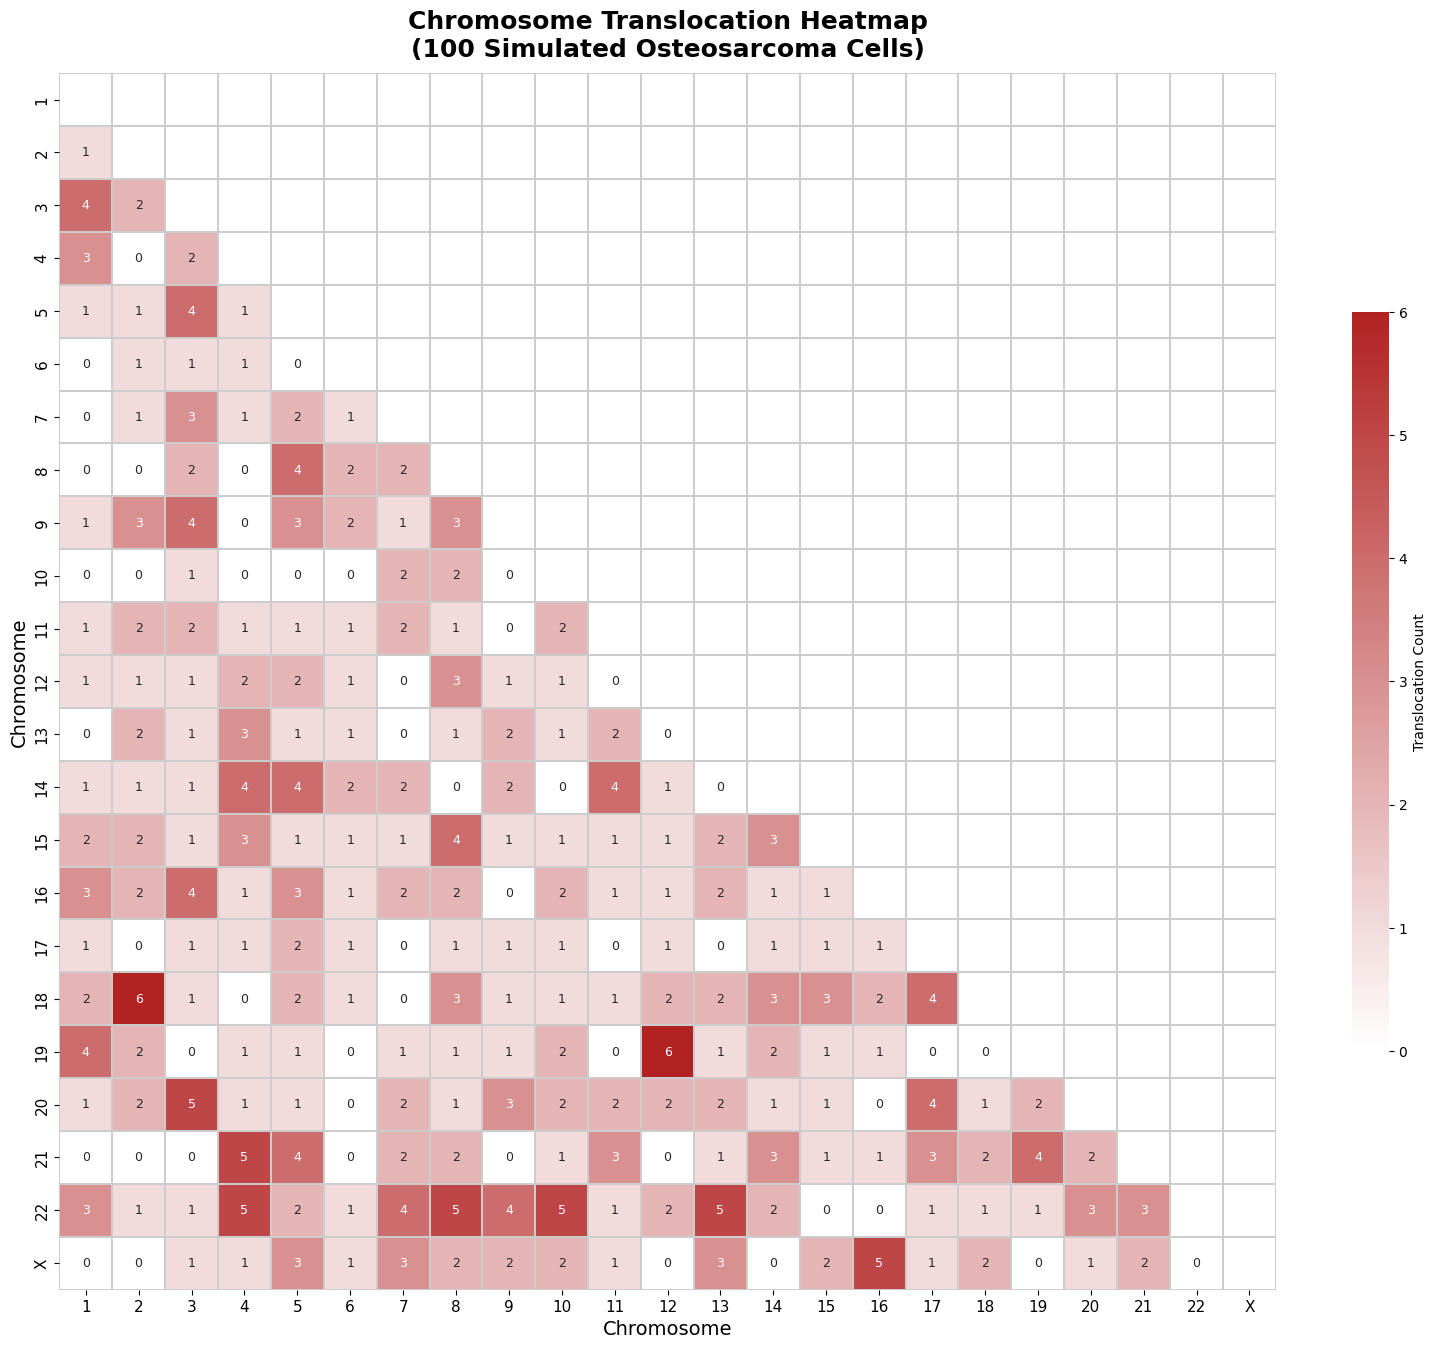

Translocation totals per chromosome:
22    50
5     43
3     42
8     41
18    40
21    39
20    39
14    38
4     36
16    36


In [12]:
# ─── Figure 1: Chromosome Interaction Heatmap (Translocations) ───────────────
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Build symmetric translocation count matrix (CHROM × CHROM)
trans_matrix = pd.DataFrame(0, index=CHROMS, columns=CHROMS)
for cell_svs in sv_log:
    for sv in cell_svs:
        if sv['type'] == 'translocation':
            d, r = sv['donor'], sv['recipient']
            trans_matrix.loc[d, r] += 1
            trans_matrix.loc[r, d] += 1

# Rename axes to short labels (1, 2, … 22, X)
trans_matrix.index   = chr_labels
trans_matrix.columns = chr_labels

# Mask upper triangle + diagonal (show lower triangle only)
mask = np.triu(np.ones_like(trans_matrix, dtype=bool), k=0)

white_red = LinearSegmentedColormap.from_list('white_red', ['#ffffff', 'firebrick'])

fig, ax = plt.subplots(figsize=(16, 14))
fig.patch.set_facecolor('white')

sns.heatmap(trans_matrix, mask=mask, cmap=white_red,
            annot=True, fmt='d', square=True,
            linewidths=0.3, linecolor='#cccccc',
            cbar_kws={'label': 'Translocation Count', 'shrink': 0.55},
            annot_kws={'size': 9}, ax=ax)

ax.set_title('Chromosome Translocation Heatmap\n(100 Simulated Osteosarcoma Cells)',
             fontsize=18, fontweight='bold', pad=12)
ax.set_xlabel('Chromosome', fontsize=14)
ax.set_ylabel('Chromosome', fontsize=14)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig('translocation_heatmap.svg', format='svg', bbox_inches='tight')
plt.savefig('translocation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Translocation totals per chromosome:")
print(trans_matrix.sum(axis=0).sort_values(ascending=False).head(10).to_string())


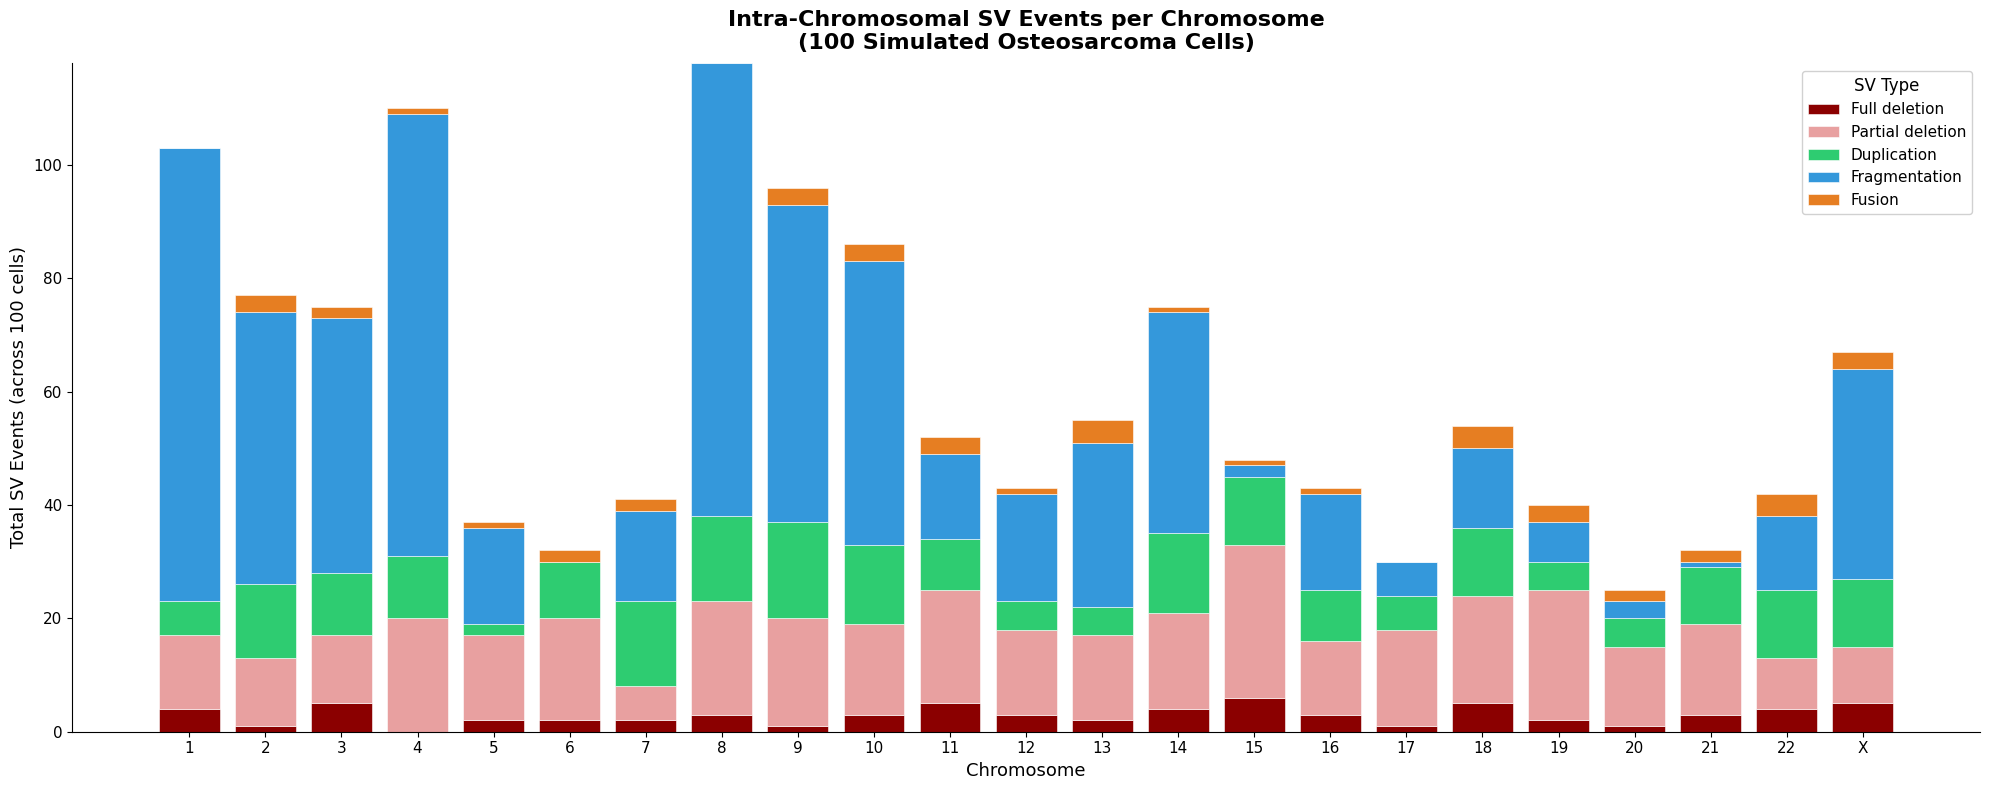


Top 5 most-affected chromosomes (total intra-chr SVs):
8     118
4     110
1     103
9      96
10     86


In [13]:
# ─── Figure 2: Intra-Chromosomal SV Stacked Barchart ─────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# SV types that are intra-chromosomal (one chromosome involved)
INTRA_TYPES  = ['full_deletion', 'partial_deletion', 'duplication', 'fragmentation', 'fusion']
INTRA_LABELS = ['Full deletion', 'Partial deletion', 'Duplication', 'Fragmentation', 'Fusion']
INTRA_COLORS = ['#8B0000', '#e8a0a0', '#2ecc71', '#3498db', '#e67e22']

# Count events per (chrom, type) across all cells
intra_counts = {t: {c: 0 for c in CHROMS} for t in INTRA_TYPES}

for cell_svs in sv_log:
    for sv in cell_svs:
        t = sv['type']
        if t == 'translocation':
            continue
        elif t == 'fusion':
            for key in ('chrom1', 'chrom2'):
                c = sv.get(key)
                if c and c in intra_counts['fusion']:
                    intra_counts['fusion'][c] += 1
        elif t in intra_counts:
            c = sv.get('chrom')
            if c:
                intra_counts[t][c] += 1

# Build DataFrame (rows = chromosomes, cols = SV types)
stacked_df = pd.DataFrame(intra_counts, index=CHROMS)[INTRA_TYPES]
stacked_df.index = chr_labels   # short labels: 1, 2, … 22, X

fig, ax = plt.subplots(figsize=(20, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bottom = np.zeros(len(chr_labels))
bars_list = []
for col, label, color in zip(INTRA_TYPES, INTRA_LABELS, INTRA_COLORS):
    vals = stacked_df[col].values
    b = ax.bar(chr_labels, vals, bottom=bottom, color=color,
               label=label, edgecolor='white', linewidth=0.4)
    bars_list.append(b)
    bottom += vals

ax.set_title('Intra-Chromosomal SV Events per Chromosome\n(100 Simulated Osteosarcoma Cells)',
             fontsize=16, fontweight='bold', pad=10)
ax.set_xlabel('Chromosome', fontsize=13)
ax.set_ylabel('Total SV Events (across 100 cells)', fontsize=13)
ax.legend(title='SV Type', fontsize=11, title_fontsize=12,
          framealpha=0.9, loc='upper right')
ax.tick_params(axis='both', labelsize=11)
ax.set_xticks(range(len(chr_labels)))
ax.set_xticklabels(chr_labels, rotation=0)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('intra_chr_sv_barchart.svg', format='svg', bbox_inches='tight')
plt.savefig('intra_chr_sv_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most-affected chromosomes (total intra-chr SVs):")
print(stacked_df.sum(axis=1).sort_values(ascending=False).head(5).to_string())


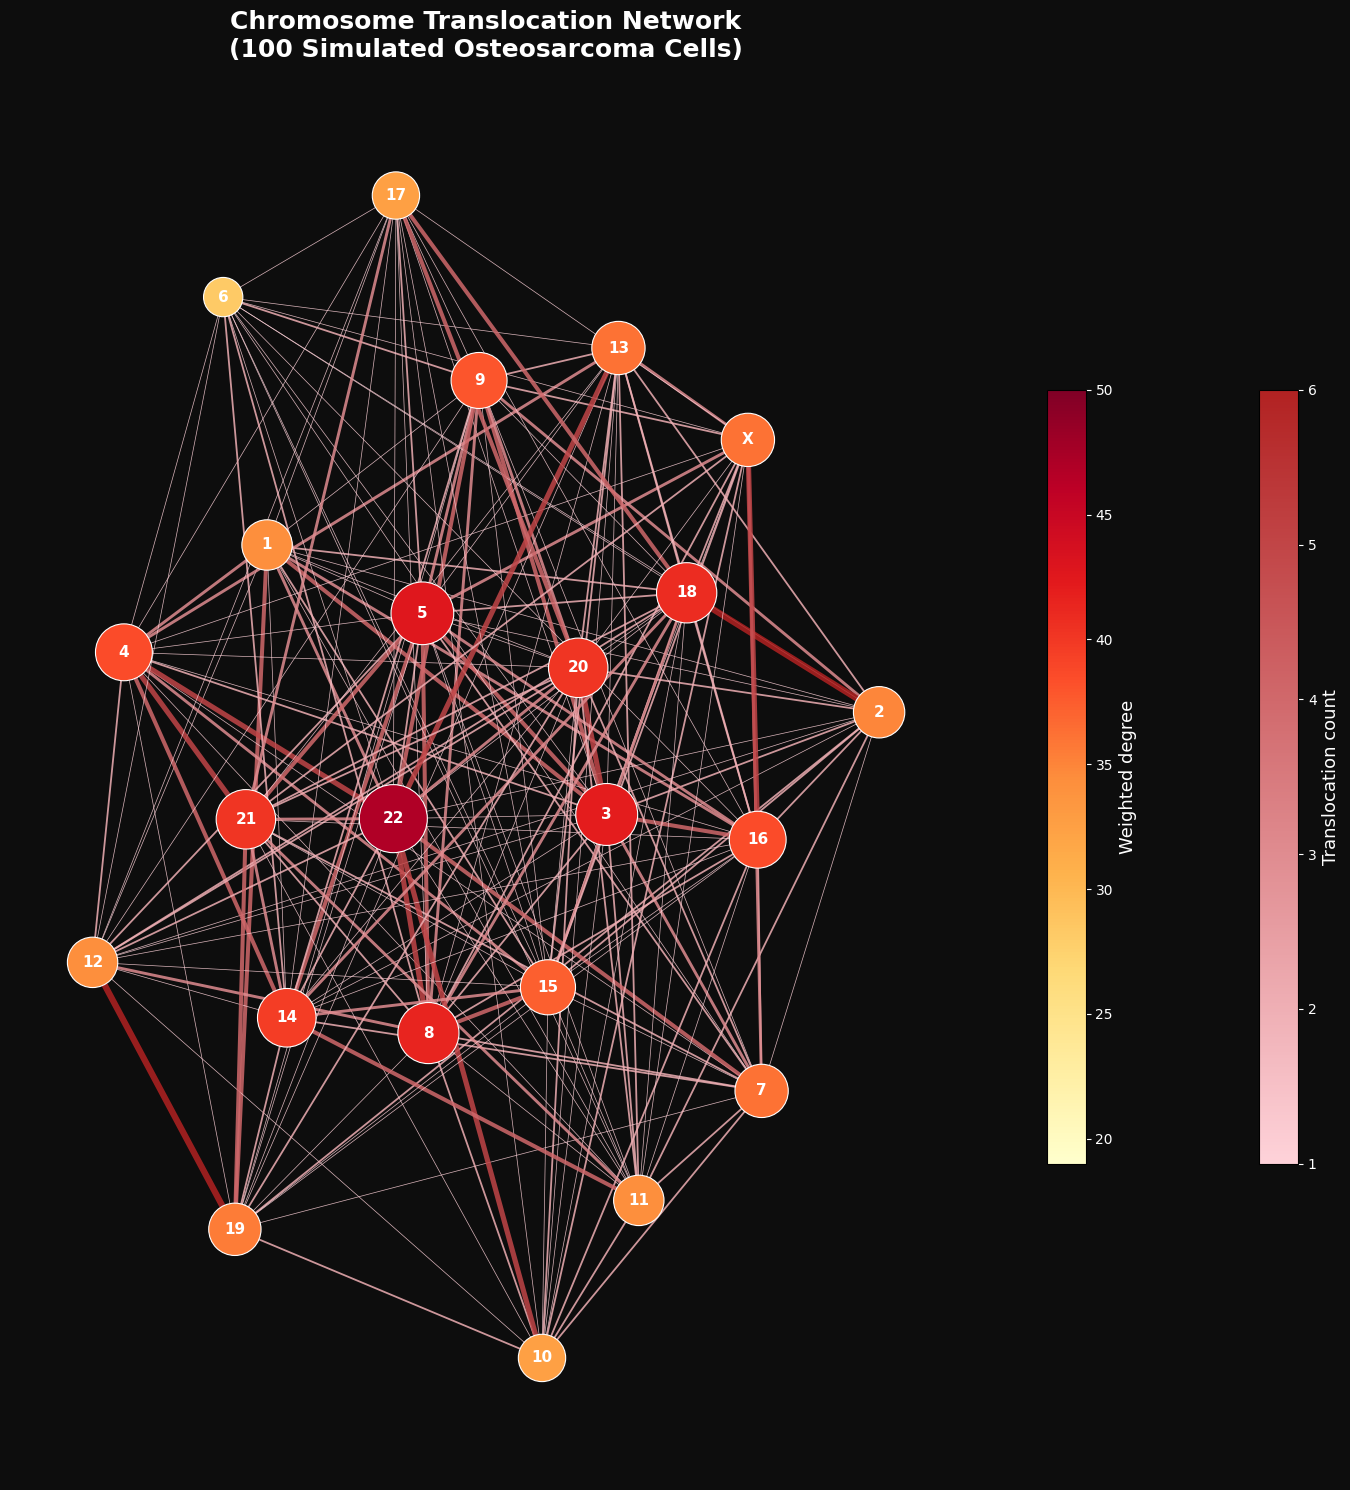

Top 5 chromosomes by translocation count:
  chr22: 50
  chr5: 43
  chr3: 42
  chr8: 41
  chr18: 40


In [14]:
# ─── Figure 3: Chromosome Interaction Network ─────────────────────────────────
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Reuse trans_matrix built in Figure 1
# Build edge list (lower-triangle only to avoid duplicate edges)
edges = []
for i, c1 in enumerate(chr_labels):
    for j, c2 in enumerate(chr_labels):
        if j <= i:
            continue
        w = int(trans_matrix.loc[c1, c2])
        if w > 0:
            edges.append((c1, c2, w))

G = nx.Graph()
G.add_nodes_from(chr_labels)
for a, b, w in edges:
    G.add_edge(a, b, weight=w)

# Remove isolated nodes (no translocations involving them)
G.remove_nodes_from(list(nx.isolates(G)))

# Layout: circular for chromosomes, emphasises inter-chr structure
pos = nx.spring_layout(G, weight='weight', seed=42, k=2.2)

# Edge styling
edge_weights = np.array([G[u][v]['weight'] for u, v in G.edges()])
w_min, w_max = edge_weights.min(), edge_weights.max()
norm_w = (edge_weights - w_min) / (w_max - w_min + 1e-9)

cmap_edges = LinearSegmentedColormap.from_list('white_red', ['#fed2d9', 'firebrick'])
edge_colors = cmap_edges(norm_w)
edge_widths  = 0.5 + 4.0 * norm_w     # scale width 0.5–4.5 px

# Node colour = total translocation degree
node_degrees = dict(G.degree(weight='weight'))
node_vals    = np.array([node_degrees[n] for n in G.nodes()])
n_min, n_max = node_vals.min(), node_vals.max()
norm_nodes   = (node_vals - n_min) / (n_max - n_min + 1e-9)
cmap_nodes   = plt.cm.YlOrRd
node_colors  = cmap_nodes(0.3 + 0.6 * norm_nodes)
node_sizes   = 800 + 1600 * norm_nodes

fig, ax = plt.subplots(figsize=(15, 15))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

# Draw edges
nx.draw_networkx_edges(G, pos, width=edge_widths,
                       edge_color=edge_colors, alpha=0.85, ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=node_colors, edgecolors='white',
                       linewidths=0.8, ax=ax)

# Labels
nx.draw_networkx_labels(G, pos, font_size=11, font_color='white',
                        font_weight='bold', ax=ax)

# Colorbars
sm_e = plt.cm.ScalarMappable(cmap=cmap_edges,
                              norm=plt.Normalize(vmin=w_min, vmax=w_max))
sm_e.set_array([])
cb_e = plt.colorbar(sm_e, ax=ax, shrink=0.55, pad=0.02, location='right')
cb_e.set_label('Translocation count', fontsize=13, color='white')
cb_e.ax.yaxis.set_tick_params(color='white')
plt.setp(cb_e.ax.yaxis.get_ticklabels(), color='white')

sm_n = plt.cm.ScalarMappable(cmap=cmap_nodes,
                              norm=plt.Normalize(vmin=n_min, vmax=n_max))
sm_n.set_array([])
cb_n = plt.colorbar(sm_n, ax=ax, shrink=0.55, pad=0.07, location='right')
cb_n.set_label('Weighted degree', fontsize=13, color='white')
cb_n.ax.yaxis.set_tick_params(color='white')
plt.setp(cb_n.ax.yaxis.get_ticklabels(), color='white')

ax.set_title('Chromosome Translocation Network\n(100 Simulated Osteosarcoma Cells)',
             fontsize=18, fontweight='bold', color='white', pad=12)
ax.axis('off')

plt.tight_layout()
plt.savefig('chr_translocation_network.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor(), transparent=False)
plt.show()

# Print top 5 most-connected chromosomes
top5 = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 chromosomes by translocation count:")
for chrom, deg in top5:
    print(f"  chr{chrom}: {deg}")
